# One dimensional dummy problem

In this section the goal will be to solve the 1 dimensional dummy problem for a first step to pressure gradients

\begin{equation}
\begin{aligned}
\rho \partial_t v &=-RT\partial_x\rho+\mu\partial_x^2 v \\
\partial_t\rho&=-(\partial_x \rho)v-\rho (\partial_x v)
\end{aligned}
\end{equation}

under IC:

\begin{equation}
\left\{ \begin{aligned}
\rho(x,0) &= 1 \\
v(x,0) &= 0
\end{aligned}\right.
\end{equation}

and BC:
\begin{equation}
\left\{\begin{aligned}
\rho(0,t) &= 2-e^{-10t} \\
\partial_x v(0,t) &= 0 \\
v(L,t) &= 0
\end{aligned}\right.
\end{equation}

In [1]:
using OrdinaryDiffEq, MethodOfLines, DomainSets, ModelingToolkit;

## Definitions

In [1]:
# Parameters, variables, and derivatives
@parameters t x
@variables ρ(..) v(..)

# definitions of derivatives
Dt = Differential(t)
Dx = Differential(x)
Dxx = Differential(x)^2

# constants
R = 1.0
T = 1.0
μ = 1.0

# PDE
eq = [
    Dt(v(t, x)) ~ (-R*T*Dx(ρ(t, x))+μ*Dxx(v(t, x)))/ρ(t, x),
    Dt(ρ(t, x)) ~ -Dx(ρ(t, x))*v(t, x)-ρ(t, x)*Dx(v(t, x))
]

# Boundary conditions
bcs = [
    ρ(0, x) ~ 1.0,
    v(0, x) ~ 0.0,
    ρ(t,0) ~ 2.0 -exp(-10.0*t),
    Dx(v(t, 0)) ~ 0.0,
    v(t, 1) ~ 0.0
]

# Space and time domains
domains = [
    t ∈ Interval(0.0, 8.0),
    x ∈ Interval(0.0, 1.0)
]

LoadError: LoadError: UndefVarError: `@parameters` not defined in `Main`
Suggestion: check for spelling errors or missing imports.
in expression starting at c:\Users\noudh\uni\MEP\3. rho time derivative\jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_W4sZmlsZQ==.jl:2

## PDE

In [6]:
# PDE system
@named pdesys = PDESystem(
    eq, 
    bcs, 
    domains, 
    [t, x], [ρ(t, x), v(t, x)]
)

PDESystem
Equations: Equation[ρ(t, x)*Differential(t, 1)(v(t, x)) ~ Differential(x, 2)(v(t, x)) - Differential(x, 1)(ρ(t, x)), Differential(t, 1)(ρ(t, x)) ~ -ρ(t, x)*Differential(x, 1)(v(t, x)) - Differential(x, 1)(ρ(t, x))*v(t, x)]
Boundary Conditions: Equation[ρ(0, x) ~ 1.0, v(0, x) ~ 0.0, ρ(t, 0) ~ 2.0 - exp(-10.0t), Differential(x, 1)(v(t, 0)) ~ 0.0, v(t, 1) ~ 0.0]
Domain: Symbolics.VarDomainPairing[Symbolics.VarDomainPairing(t, 0.0 .. 8.0), Symbolics.VarDomainPairing(x, 0.0 .. 1.0)]
Dependent Variables: Num[ρ(t, x), v(t, x)]
Independent Variables: Num[t, x]
Parameters: SciMLBase.NullParameters()
Default Parameter ValuesModelingToolkitBase.AtomicArrayDict{SymbolicUtils.BasicSymbolicImpl.var"typeof(BasicSymbolicImpl)"{SymReal}, Dict{SymbolicUtils.BasicSymbolicImpl.var"typeof(BasicSymbolicImpl)"{SymReal}, SymbolicUtils.BasicSymbolicImpl.var"typeof(BasicSymbolicImpl)"{SymReal}}}()

In [10]:
# PDE system
@named pdesys = PDESystem(
    eq, 
    bcs, 
    domains, 
    [t, x], [ρ(t, x), v(t, x)]
)
# Method of lines discretization
dx = .02
order = 2
# scheme = UpwindScheme(approx_order = 1)
discretization = MOLFiniteDifference([x => dx], t)

# Convert the PDE problem into an ODE problem
prob = discretize(pdesys, discretization);

In [ ]:
?discretize

UndefVarError: UndefVarError: `help` not defined in `Main`
Suggestion: check for spelling errors or missing imports.
  Welcome to Julia 1.12.5. The full manual is available at

  https://docs.julialang.org

  as well as many great tutorials and learning resources:

  https://julialang.org/learning/

  For help on a specific function or macro, type ? followed by its name, e.g.
  ?cos, or ?@time, and press enter. Type ; to enter shell mode, ] to enter
  package mode.

  To exit the interactive session, type CTRL-D (press the control key together
  with the d key), or type exit().

In [7]:
# Method of lines discretization
dx = .02
order = 2
# scheme = UpwindScheme(approx_order = 1)
discretization = MOLFiniteDifference([x => dx], t)

# Convert the PDE problem into an ODE problem
prob = discretize(pdesys, discretization);

The system of equations is:
Equation[-2500.0(v(t))[1] + 5000.0(v(t))[2] - 2500.0(v(t))[3] - 50.0(ρ(t))[1] + 50.0(ρ(t))[2] + Differential(t, 1)((v(t))[2])*(ρ(t))[2] ~ 0, -2500.0(v(t))[2] + 5000.0(v(t))[3] - 2500.0(v(t))[4] - 50.0(ρ(t))[2] + 50.0(ρ(t))[3] + Differential(t, 1)((v(t))[3])*(ρ(t))[3] ~ 0, -2500.0(v(t))[3] + 5000.0(v(t))[4] - 2500.0(v(t))[5] - 50.0(ρ(t))[3] + 50.0(ρ(t))[4] + (ρ(t))[4]*Differential(t, 1)((v(t))[4]) ~ 0, -2500.0(v(t))[4] + 5000.0(v(t))[5] - 2500.0(v(t))[6] - 50.0(ρ(t))[4] + 50.0(ρ(t))[5] + (ρ(t))[5]*Differential(t, 1)((v(t))[5]) ~ 0, -2500.0(v(t))[5] + 5000.0(v(t))[6] - 2500.0(v(t))[7] - 50.0(ρ(t))[5] + 50.0(ρ(t))[6] + Differential(t, 1)((v(t))[6])*(ρ(t))[6] ~ 0, -2500.0(v(t))[6] + 5000.0(v(t))[7] - 2500.0(v(t))[8] - 50.0(ρ(t))[6] + 50.0(ρ(t))[7] + (ρ(t))[7]*Differential(t, 1)((v(t))[7]) ~ 0, -2500.0(v(t))[7] + 5000.0(v(t))[8] - 2500.0(v(t))[9] - 50.0(ρ(t))[7] + 50.0(ρ(t))[8] + (ρ(t))[8]*Differential(t, 1)((v(t))[8]) ~ 0, -2500.0(v(t))[10] - 2500.0(v(t))[8] + 5

ModelingToolkitBase.MissingVariablesError: Initial condition underdefined. Some are missing from the variable map.
Please provide a default (`u0`), initialization equation, or guess
for the following variables:

(vˍt(t))[4], (vˍt(t))[41], (vˍt(t))[39], (vˍt(t))[7], (vˍt(t))[21], (vˍt(t))[24], (vˍt(t))[35], (vˍt(t))[37], (vˍt(t))[44], (vˍt(t))[19], (vˍt(t))[34], (vˍt(t))[20], (vˍt(t))[26], (vˍt(t))[15], (vˍt(t))[50], (vˍt(t))[43], (vˍt(t))[29], (vˍt(t))[9], (vˍt(t))[27], (vˍt(t))[46], (vˍt(t))[23], (vˍt(t))[48], (vˍt(t))[3], (vˍt(t))[12], (vˍt(t))[18], (vˍt(t))[11], (vˍt(t))[40], (vˍt(t))[36], (vˍt(t))[10], (vˍt(t))[8], (vˍt(t))[17], (vˍt(t))[32], (vˍt(t))[25], (vˍt(t))[6], (vˍt(t))[22], (vˍt(t))[5], (vˍt(t))[49], (vˍt(t))[13], (vˍt(t))[42], (vˍt(t))[33], (vˍt(t))[14], (vˍt(t))[45], (vˍt(t))[16], (vˍt(t))[31], (vˍt(t))[2], (vˍt(t))[28], (vˍt(t))[30], (vˍt(t))[47], (vˍt(t))[38]


In [11]:
# Solve ODE problem
sol = solve(prob, Tsit5(), saveat=0.1)

L"\begin{align}
\frac{ - \frac{\mathrm{d}^{2}}{\mathrm{d}x^{2}} ~ v\left( t, x \right) + \frac{\mathrm{d}}{\mathrm{d}x} ~ \rho\left( t, x \right)}{\rho\left( t, x \right)} + \frac{\mathrm{d}}{\mathrm{d}t} ~ v\left( t, x \right) &= 0 \\
\frac{\mathrm{d}}{\mathrm{d}t} ~ \rho\left( t, x \right) + \rho\left( t, x \right) ~ \frac{\mathrm{d}}{\mathrm{d}x} ~ v\left( t, x \right) + \frac{\mathrm{d}}{\mathrm{d}x} ~ \rho\left( t, x \right) ~ v\left( t, x \right) &= 0
\end{align}
"

PDESolution:
  Return Code:
    Success
  Dependent variables:
    v(t, x): (81, 51) sized solution
    ρ(t, x): (81, 51) sized solution
  Domain:
    t ∈ (0.0, 8.0) with 81 points, step size 0.1
    x ∈ (0.0, 1.0) with 51 points, step size 0.02
  From system:
    Equations:
    Boundary/Initial Conditions:


L"\begin{align}
\rho\left( 0, x \right) &= 1 \\
v\left( 0, x \right) &= 0 \\
\rho\left( t, 0 \right) &= 2 - e^{ - 10 ~ t} \\
\frac{\mathrm{d}}{\mathrm{d}x} ~ v\left( t, 0 \right) &= 0 \\
v\left( t, 1 \right) &= 0
\end{align}
"

In [14]:
sol.t

12435-element Vector{Float64}:
 0.0
 9.999999999999999e-5
 0.0002772609417397931
 0.0005062490586109217
 0.0008330802474659388
 0.0012724356489418444
 0.0018755025268164523
 0.002483924773814338
 0.0028959865651606246
 0.0032503551715846847
 ⋮
 7.994717821229636
 7.995418878846231
 7.99611993337449
 7.996820984867856
 7.997522033224825
 7.9982230785469275
 7.998924120786091
 7.999625159942329
 8.0

## Plotting/animating

In [6]:
# Plot results and compare with exact solution
discrete_x = sol[x];
discrete_t = sol[t];
sol_ρ = sol[ρ(t, x)];
sol_v = sol[v(t, x)];


folder = "a. one dimensional";
mkpath(folder);

In [7]:
# Used for plotting
using Plots

┌ Info: Saved animation to c:\Users\noudh\uni\MEP\3. rho time derivative\a. one dimensional\ρ.gif
└ @ Plots C:\Users\noudh\.julia\packages\Plots\GIume\src\animation.jl:156


Plots.AnimatedGif("c:\\Users\\noudh\\uni\\MEP\\3. rho time derivative\\a. one dimensional\\ρ.gif")
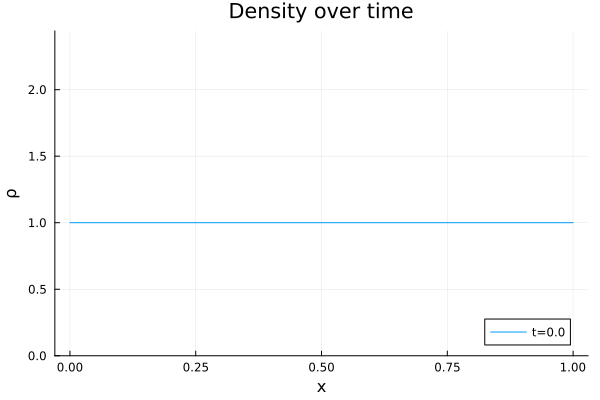

In [8]:
ymin = 0
ymax = maximum(sol_ρ)

anim = @animate for k in 1:length(discrete_t)
    plot(
        discrete_x, 
        sol_ρ[k, :], 
        title = "Density over time", 
        ylims = (ymin, ymax), 
        ylabel = "ρ",
        xlabel = "x",
        label = "t=$(discrete_t[k])",
        legend = :bottomright
    )
end

gif(anim, joinpath(folder, "ρ.gif"), fps = 8)

┌ Info: Saved animation to c:\Users\noudh\uni\MEP\3. rho time derivative\a. one dimensional\v.gif
└ @ Plots C:\Users\noudh\.julia\packages\Plots\GIume\src\animation.jl:156


Plots.AnimatedGif("c:\\Users\\noudh\\uni\\MEP\\3. rho time derivative\\a. one dimensional\\v.gif")
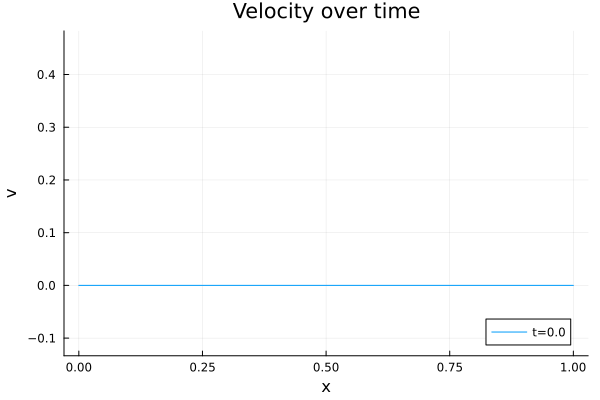

In [9]:
ymin = minimum(sol_v)
ymax = maximum(sol_v)

anim = @animate for k in 1:length(discrete_t)
    plot(
        discrete_x, 
        sol_v[k, :], 
        title = "Velocity over time", 
        ylims = (ymin, ymax), 
        ylabel = "v",
        xlabel = "x",
        label = "t=$(discrete_t[k])",
        legend = :bottomright
    )
end

gif(anim, joinpath(folder, "v.gif"), fps = 8)

┌ Info: Saved animation to c:\Users\noudh\uni\MEP\3. rho time derivative\a. one dimensional\flow.gif
└ @ Plots C:\Users\noudh\.julia\packages\Plots\GIume\src\animation.jl:156


Plots.AnimatedGif("c:\\Users\\noudh\\uni\\MEP\\3. rho time derivative\\a. one dimensional\\flow.gif")
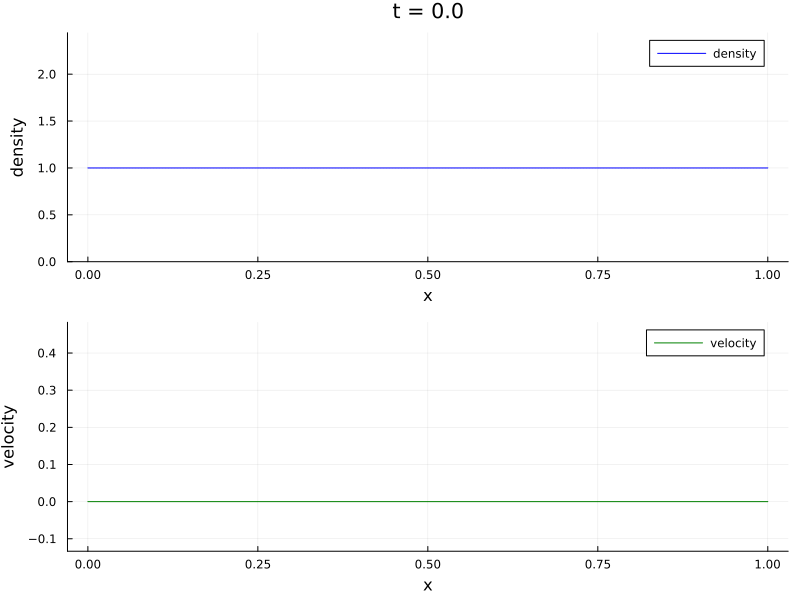

In [11]:
# limits
ρmin = minimum(sol_ρ)
ρmax = maximum(sol_ρ)

vmin = minimum(sol_v)
vmax = maximum(sol_v)

left_min = ρmin
left_max = ρmax

anim = @animate for k in 1:length(discrete_t)

    # top plot: density + total pressure
    p1 = plot(
        discrete_x,
        sol_ρ[k, :],

        label = "density",
        color = :blue,

        xlabel = "x",
        ylabel = "density",
        title = "t = $(round(discrete_t[k], digits=3))",
        ylims = (0, ρmax),
        legend = :topright)
    

    # bottom plot: velocity
    p2 = plot(
        discrete_x,
        sol_v[k, :],

        label = "velocity",
        color = :green,

        xlabel = "x",
        ylabel = "velocity",

        ylims = (vmin, vmax),

        legend = :topright
    )

    # combine vertically
    plot(
        p1,
        p2,

        layout = (2,1),
        size = (800,600)
    )

end

gif(anim, joinpath(folder, "flow.gif"), fps = 10)

### Ugly plots below

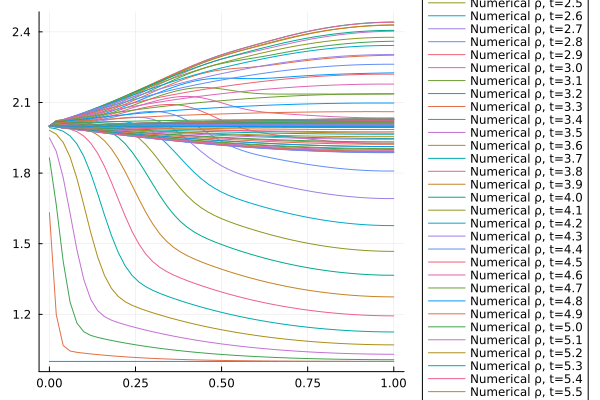

In [14]:
plt = plot(legend = :outerright)
for i in eachindex(discrete_t)
    plot!(discrete_x, sol_ρ[i, :], label = "Numerical ρ, t=$(discrete_t[i])")
end
plt

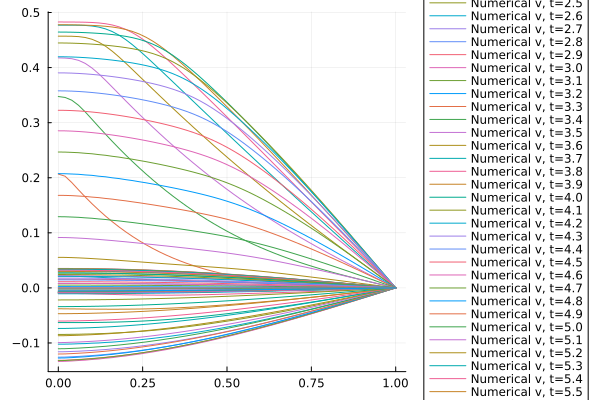

In [15]:
plt = plot(legend = :outerright)
for i in eachindex(discrete_t)
    plot!(discrete_x, sol_v[i, :], label = "Numerical v, t=$(discrete_t[i])")
end
plt